# Import libraries

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load full ground truth

In [12]:
def load_gt(gt_fname):
    with open(gt_fname) as f:
        gt = json.load(f)

    rows_gt = []
    for video_id, info in gt["database"].items():
        duration = info["duration"]
        subset = info["subset"]
        for s in info["annotations"]:
            rows_gt.append(
                {
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": s["segment"][0],
                    "end": s["segment"][1],
                    "label": s["label"],
                }
            )

    return pd.DataFrame(rows_gt)

In [13]:
gt_df = load_gt("../data/charades/annotations/charades.json")

# Function to generate sample charades

In [14]:
def sample_dataset(
    actions,
    category_idx_fname="../data/charades/annotations/sample_category_idx.txt",
    gt_fname="../data/charades/annotations/sample_charades.json",
):  
    # Save category index to a text file
    with open(category_idx_fname, "w") as f:
        for action in actions:
            f.write(action + "\n")

    # Filter rows with labels in it
    gt_df_sample = gt_df[gt_df["label"].isin(actions)].copy()

    # Save sample annotations to JSON file
    output = {"version": "Charades_v1_Sample", "database": {}}

    for video_id, group in gt_df_sample.groupby("video_id"):
        # keep duration/subset from the original gt
        duration = gt_df_sample[gt_df_sample["video_id"] == video_id]["duration"].iloc[0]
        subset = gt_df_sample[gt_df_sample["video_id"] == video_id]["subset"].iloc[0]

        annotations = []
        for _, row in group.iterrows():
            annotations.append(
                {"segment": [row["start"], row["end"]], "label": row["label"]}
            )
        output["database"][video_id] = {
            "duration": duration,
            "subset": subset,
            "annotations": annotations,
        }

    with open(gt_fname, "w") as f:
        json.dump(output, f, indent=2)

### Sample the 10 least frequent classes

In [15]:
# Create sample classes and save them to a file
least_sample_classes = sorted(
    gt_df["label"].value_counts()[-10:].index.tolist()
)  # Select the 10 least frequent classes

sample_dataset(
    least_sample_classes,
    category_idx_fname="../data/charades/annotations/least_sample_category_idx.txt",
    gt_fname="../data/charades/annotations/least_sample_charades.json",
)

<Axes: title={'center': 'Number of videos per class in the least sample ground truth - training subset'}, xlabel='label'>

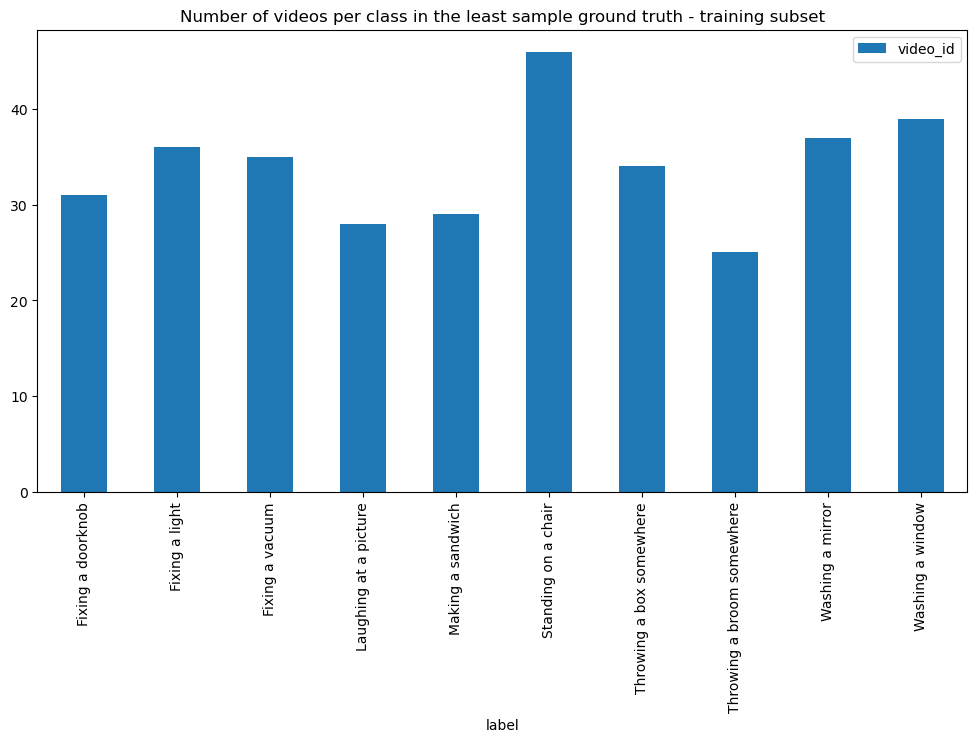

In [16]:
# Explore the sample ground truth
least_sample_gt_df = load_gt("../data/charades/annotations/least_sample_charades.json")

least_sample_gt_df[least_sample_gt_df["subset"] == "training"].groupby("label").agg(
    {"video_id": "nunique"}
).plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of videos per class in the least sample ground truth - training subset",
)

<Axes: title={'center': 'Number of videos per class in the least sample ground truth - testing subset'}, xlabel='label'>

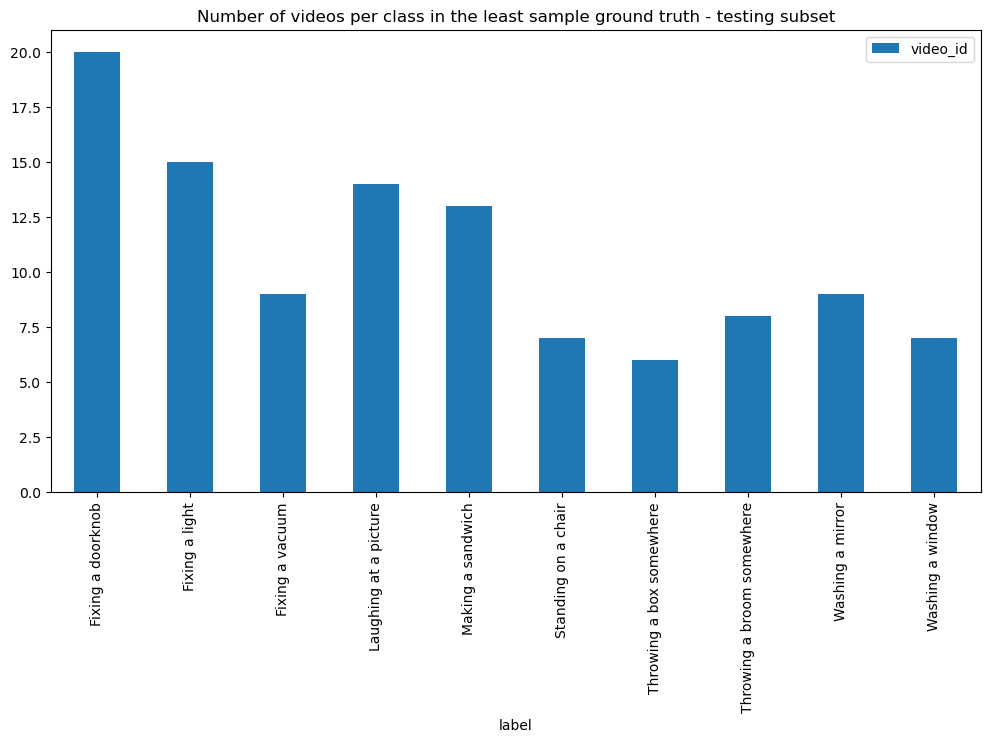

In [17]:
least_sample_gt_df[least_sample_gt_df["subset"] == "testing"].groupby("label").agg(
    {"video_id": "nunique"}
).plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of videos per class in the least sample ground truth - testing subset",
)

### Sample the 10 most frequent classes

In [18]:
# Create sample classes and save them to a file
most_sample_classes = sorted(
    gt_df["label"].value_counts()[:10].index.tolist()
)  # Select the 10 most frequent classes

sample_dataset(
    most_sample_classes,
    category_idx_fname="../data/charades/annotations/most_sample_category_idx.txt",
    gt_fname="../data/charades/annotations/most_sample_charades.json",
)

<Axes: title={'center': 'Number of videos per class in the most sample ground truth - training subset'}, xlabel='label'>

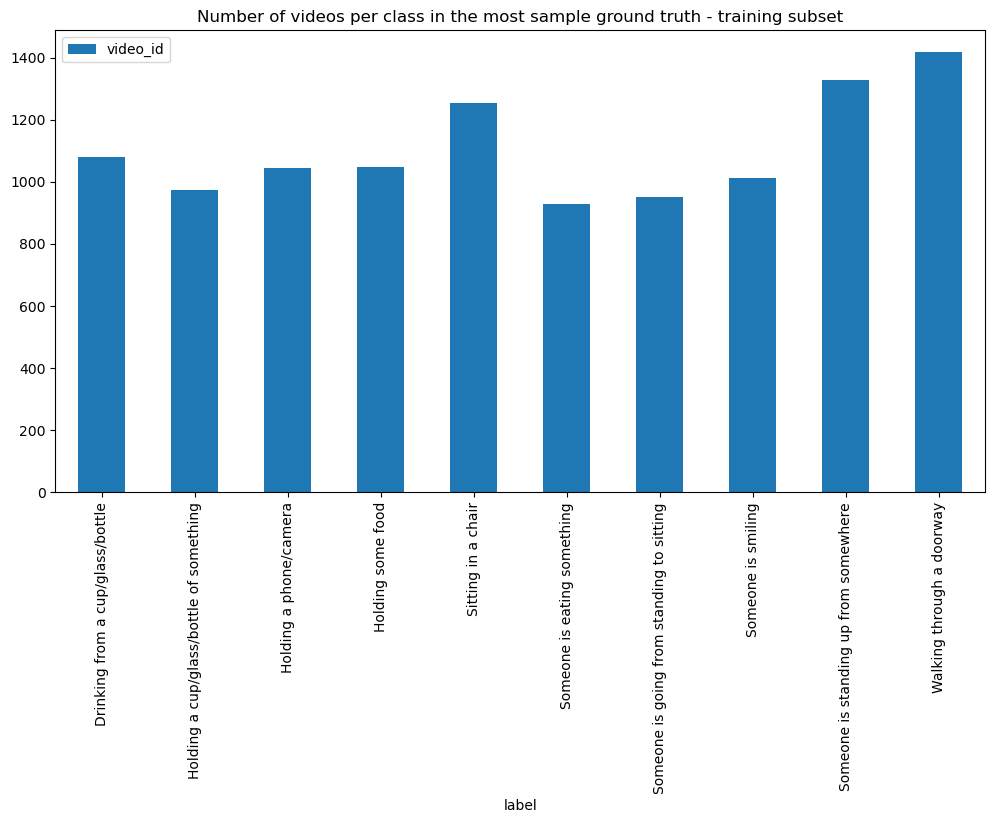

In [19]:
# Explore the sample ground truth
most_sample_gt_df = load_gt("../data/charades/annotations/most_sample_charades.json")

most_sample_gt_df[most_sample_gt_df["subset"] == "training"].groupby("label").agg(
    {"video_id": "nunique"}
).plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of videos per class in the most sample ground truth - training subset",
)

<Axes: title={'center': 'Number of videos per class in the most sample ground truth - testing subset'}, xlabel='label'>

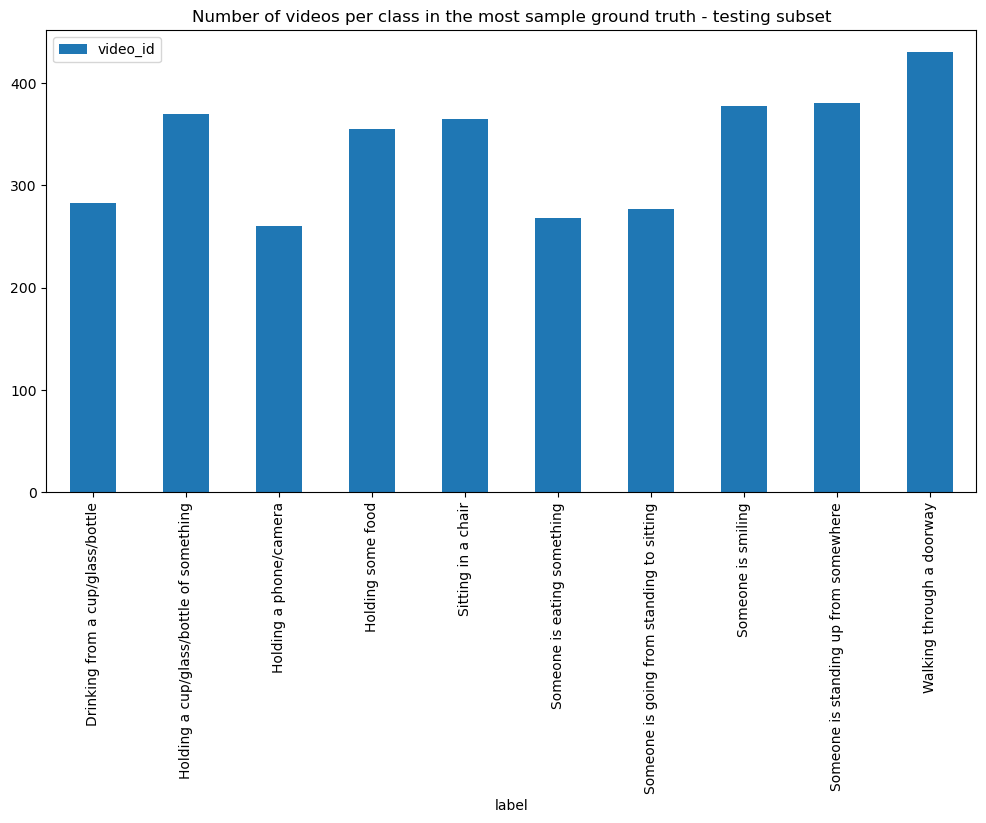

In [20]:
most_sample_gt_df[most_sample_gt_df["subset"] == "testing"].groupby("label").agg(
    {"video_id": "nunique"}
).plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of videos per class in the most sample ground truth - testing subset",
)